In [19]:
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
import numpy as np
df=pd.read_csv("car.csv")

In [20]:
df.head()

,customer name,customer e-mail,annual Salary,credit card debt,net worth,car model,Fuel,Brand,No. of seats,Transmission,Mileage,Car purchase amount
0,Martina Avila,cubilia.Curae.Phasellus@quisaccumsanconvallis.edu,202812,11609,238905.0,medium,Petrol,TATA,4,Automatic,16,653210
1,Harlan Barnes,eu.dolor@diam.co.uk,212812,95728,1039078.0,medium,Diesel,TOYOTA,5,Automatic,15,1053210
2,Naomi Rodriquez,vulputate.mauris.sagittis@ametconsectetueradip...,222812,11160,1039078.0,top,Diesel,MAHINDRA,5,Automatic,15,1383210
3,Jade Cunningham,malesuada@dignissim.com,232812,14425,1039078.0,top,Diesel,MAHINDRA,7,Automatic,17,1383210
4,Cedric Leach,felis.ullamcorper.viverra@egetmollislectus.net,232812,53589,1039078.0,top,Diesel,MAHINDRA,7,Automatic,17,1383210


In [21]:
df.shape

(56, 12)

In [22]:
df.describe()

,annual Salary,credit card debt,net worth,No. of seats,Mileage,Car purchase amount
count,56.000000,56.000000,4.800000e+01,56.000000,56.000000,5.600000e+01
mean,234300.482143,17016.892857,1.675535e+06,5.178571,16.392857,1.598010e+06
std,155958.233468,20216.819444,1.665136e+06,1.097222,1.316726,1.536351e+06
min,100000.000000,1851.000000,1.880780e+05,4.000000,14.000000,3.632100e+05
25%,139628.000000,9097.000000,4.820562e+05,4.000000,15.000000,5.976108e+05
50%,170887.000000,11373.000000,1.039078e+06,5.000000,16.000000,9.194145e+05
75%,242812.000000,13268.250000,1.766026e+06,6.000000,18.000000,1.530170e+06
max,613819.000000,95728.000000,5.053932e+06,7.000000,19.000000,4.659080e+06


In [23]:
df.isnull().sum()

customer name          0
customer e-mail        0
annual Salary          0
credit card debt       0
net worth              8
car model              0
Fuel                   0
Brand                  0
No. of seats           0
Transmission           0
Mileage                0
Car purchase amount    0
dtype: int64

In [24]:
df['net worth']=df['net worth'].fillna(df['net worth'].mean())

In [25]:
df.isnull().sum()

customer name          0
customer e-mail        0
annual Salary          0
credit card debt       0
net worth              0
car model              0
Fuel                   0
Brand                  0
No. of seats           0
Transmission           0
Mileage                0
Car purchase amount    0
dtype: int64

In [26]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 56 entries, 0 to 55
Data columns (total 12 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   customer name        56 non-null     object 
 1   customer e-mail      56 non-null     object 
 2   annual Salary        56 non-null     int64  
 3   credit card debt     56 non-null     int64  
 4   net worth            56 non-null     float64
 5   car model            56 non-null     object 
 6   Fuel                 56 non-null     object 
 7   Brand                56 non-null     object 
 8   No. of seats         56 non-null     int64  
 9   Transmission         56 non-null     object 
 10  Mileage              56 non-null     int64  
 11  Car purchase amount  56 non-null     int64  
dtypes: float64(1), int64(5), object(6)
memory usage: 5.4+ KB


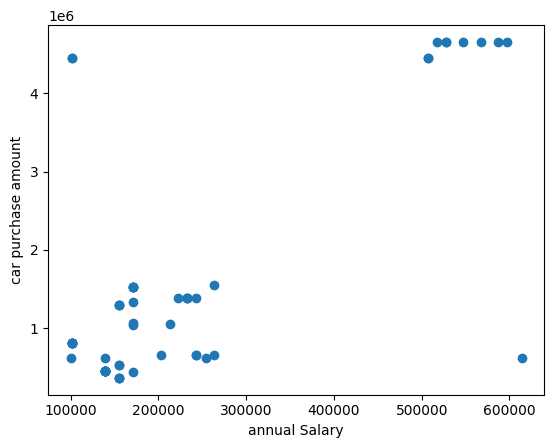

In [27]:
import matplotlib.pyplot as plt
plt.scatter(df['annual Salary'],df['Car purchase amount'])
plt.xlabel('annual Salary')
plt.ylabel('car purchase amount')
plt.show()

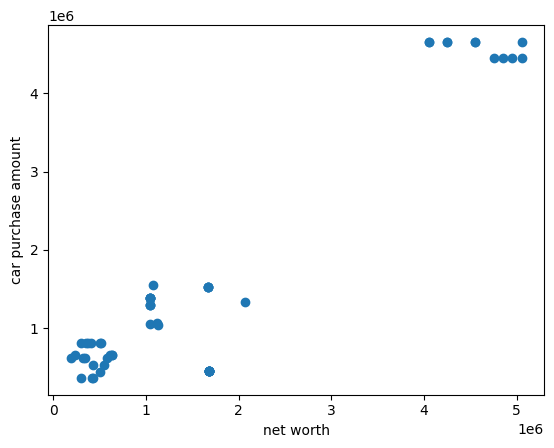

In [28]:
plt.scatter(df['net worth'],df['Car purchase amount'])
plt.xlabel('net worth')
plt.ylabel('car purchase amount')
plt.show()

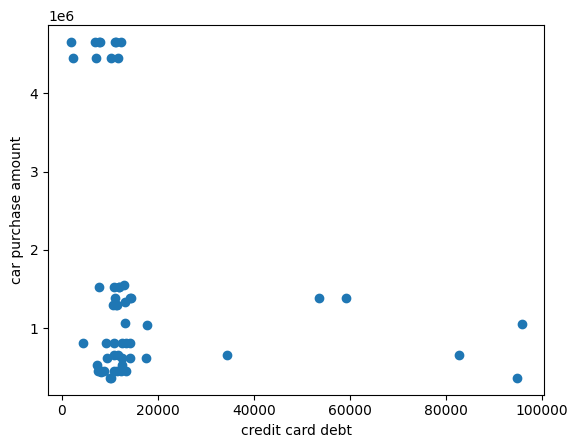

In [29]:
plt.scatter(df['credit card debt'],df['Car purchase amount'])
plt.xlabel('credit card debt')
plt.ylabel('car purchase amount')
plt.show()

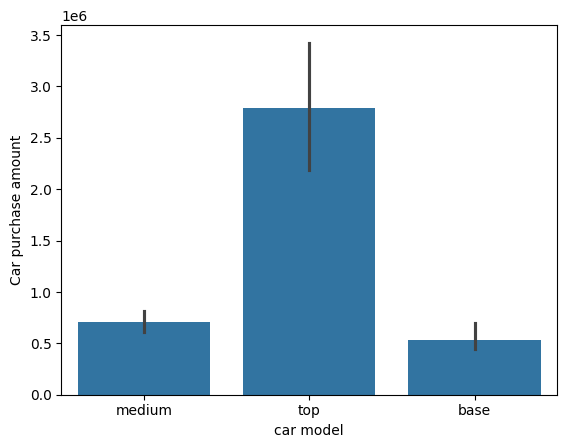

In [30]:
import seaborn as sns
sns.barplot(x=df['car model'],y=df['Car purchase amount'],data=df)
plt.show()

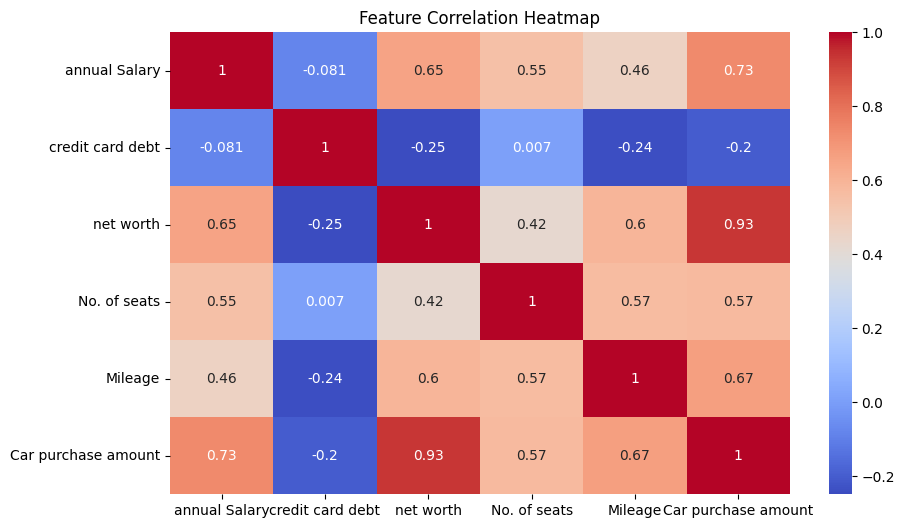

In [31]:
corr=df.corr(numeric_only=True)
plt.figure(figsize=(10,6))
sns.heatmap(corr,annot=True,cmap='coolwarm')
plt.title('Feature Correlation Heatmap')
plt.show()

In [32]:
le=LabelEncoder()
cols=['car model','Fuel','Brand','Transmission']
df[cols]= df[cols].apply(LabelEncoder().fit_transform)
df

,customer name,customer e-mail,annual Salary,credit card debt,net worth,car model,Fuel,Brand,No. of seats,Transmission,Mileage,Car purchase amount
0,Martina Avila,cubilia.Curae.Phasellus@quisaccumsanconvallis.edu,202812,11609,2.389050e+05,1,1,4,4,0,16,653210
1,Harlan Barnes,eu.dolor@diam.co.uk,212812,95728,1.039078e+06,1,0,5,5,0,15,1053210
2,Naomi Rodriquez,vulputate.mauris.sagittis@ametconsectetueradip...,222812,11160,1.039078e+06,2,0,2,5,0,15,1383210
3,Jade Cunningham,malesuada@dignissim.com,232812,14425,1.039078e+06,2,0,2,7,0,17,1383210
4,Cedric Leach,felis.ullamcorper.viverra@egetmollislectus.net,232812,53589,1.039078e+06,2,0,2,7,0,17,1383210
5,Carla Hester,mi@Aliquamerat.edu,232812,14179,1.039078e+06,0,0,2,4,0,14,1383210
6,Griffin Rivera,vehicula@at.co.uk,242812,59188,1.039078e+06,2,0,2,7,0,15,1383210
7,Orli Casey,nunc.est.mollis@Suspendissetristiqueneque.co.uk,242812,10956,6.293110e+05,1,1,4,4,1,15,653210
8,Marny Obrien,Phasellus@sedsemegestas.org,242812,34409,6.300540e+05,1,1,4,4,1,15,653210
9,Rhonda Chavez,nec@nuncest.com,262812,12888,1.076644e+06,2,0,2,5,0,17,1553210


In [33]:
x=df.drop(df.columns[[0,1,11]],axis=1)
y=df['Car purchase amount']

In [34]:
x.shape

(56, 9)

In [35]:
y.shape

(56,)

In [36]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.30,random_state=67)

In [37]:
x_train.shape

(39, 9)

In [38]:
y_train.shape

(39,)

In [39]:
x_test.shape

(17, 9)

In [40]:
y_test.shape

(17,)

In [41]:
model=LinearRegression()
model.fit(x_train,y_train)


,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [42]:
y_pred=model.predict(x_test)
y_pred

array([ 690164.8815937 ,  618798.96935883,  377771.07689616,
        593748.27820232, 1465518.58896132,  609859.35844559,
       1078113.01541243, 4498146.45135286, 1987064.37005237,
        839123.04631095, 1567959.31053213, 4388899.48801335,
        839472.85226008,  272260.31293018,  359141.70402557,
       4249309.61754877,  617422.19174551])

In [43]:
from sklearn.metrics import mean_absolute_error,mean_squared_error, r2_score
print('mae:',mean_absolute_error(y_test,y_pred))
print('rmse:',np.sqrt(mean_squared_error(y_test,y_pred)))
print('r2score:',r2_score(y_test,y_pred)*100,'%')

mae: 248543.7540859875
rmse: 290900.1692362912
r2score: 95.98690778309468 %


In [44]:
#save model

import pickle
with open('CarPurchaseAmount.pkl','wb') as f:
    pickle.dump(model,f)
print('model saved')

model saved


In [45]:
#load model
with open('CarPurchaseAmount.pkl','rb') as f:
    loaded_model=pickle.load(f)
print('model loaded')
 

model loaded
